In [2]:
# Eval Regression – q3 vs IQR/RMS, residuals by energy, IQR vs training samples (bin 2)
# Plots saved as PDFs in out/regression_eval
import matplotlib
from matplotlib import font_manager

# Point directly to one of the Arial TTF files we just unpacked
arial_path = "/global/homes/g/gregork/.local/share/fonts/ARIAL.TTF"
# Register this font with Matplotlib
font_manager.fontManager.addfont(arial_path)
matplotlib.rcParams["font.family"] = ["Arial", "sans-serif"]
import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
if str(ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(ROOT / "notebooks"))

CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")
OUT_DIR = ROOT / "out" / "regression_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

WANDB_TAG = "Run_1203"  # wandb tag to select runs (set as needed)

In [3]:
# Build model -> runs for full dataset (cap=-1) and for scaling (all caps)
from src.utils.utils import get_runs_by_model_and_cap

runs_by_model_cap = get_runs_by_model_and_cap(WANDB_TAG)

# Full-dataset runs: one run per model (cap=-1)
training_names_full = {"Log1p": {}}
baseline_run = None
for model, caps in runs_by_model_cap.items():
    if -1 in caps.keys():
        run = caps[-1]
        training_names_full["Log1p"][model] = run
        if baseline_run is None:
            baseline_run = run[-1]

if not training_names_full["Log1p"]:
    raise SystemExit("No runs with cap=-1 found. Check WANDB_TAG and wandb.")
if baseline_run is None:
    baseline_run = list(training_names_full["Log1p"].values())[0]
print("Full-dataset models:", list(training_names_full["Log1p"].keys()))
print("Baseline run for filters/baselines:", baseline_run)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /global/homes/g/gregork/.netrc.


Calling wandb API...
  Fetching runs from fcc_ml/minerva-models with tag 'Run_1203'...
  Wandb API finished: 102 run(s) found with tag 'Run_1203'.
Full-dataset models: ['MLP', 'Transformer', 'OmniLearned-small', 'OmniLearned-medium']
Baseline run for filters/baselines: Run_cond_only_full_seed46_20260316_223526


In [21]:
# print dict of runs
print(training_names_full)
print({key: len(value) for key, value in training_names_full["Log1p"].items()})

{'Log1p': {'MLP': ['Run_cond_only_full_seed42_20260314_165943', 'Run_cond_only_full_seed45_20260316_152957', 'Run_cond_only_full_seed43_20260315_235708', 'Run_cond_only_full_seed46_20260316_223526'], 'Transformer': ['Run_1203_regression_Transformer1_data_cap_-1_seed_44_20260315_235600', 'Run_1203_regression_Transformer1_data_cap_-1_seed_45_20260316_022020', 'Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412', 'Run_1203_regression_Transformer1_data_cap_-1_seed_43_20260315_193857'], 'OmniLearned-small': ['Run_1203_OLS_regression_-1_seed45_20260316_005939', 'Run_1203_OLS_regression_-1_seed44_20260315_224857', 'Run_1203_OLS_regression_-1_seed42_20260312_201942'], 'OmniLearned-medium': ['Run_1203_OLM_regression_-1_seed42_20260314_060257']}}
{'MLP': 4, 'Transformer': 4, 'OmniLearned-small': 3, 'OmniLearned-medium': 1}


## (I) q3 vs IQR and RMS – full training dataset

keys:  dict_keys(['1B', '1A'])
  baseline: RMS = [3.148372598935032, 2.7791810405009967, 2.2176398351942384, 1.758116717480389, 1.504561280576312, 1.4609254305037722], IQR = [1.571619917564179, 1.0746723295343061, 0.7115179810480453, 0.5896458729592533, 0.5301364134724922, 0.4837199325457493], MPV = [1.19, 0.99, 0.91, 0.87, 0.87, 0.85]
E_pred_dict keys for '1A': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer§0', 'Transformer§1', 'Transformer§2', 'Transformer§3', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-medium§0']}
  MLP (Log1p):
    RMS = [3.1814438700675964, 2.6627307534217834, 1.8577376008033752, 1.414291799068451, 1.2435448169708252, 1.1934764683246613]
    IQR = [1.5256316363811493, 0.9385534524917603, 0.6366978585720062, 0.5337332934141159, 0.48613882064819336, 0.448309987783432]
    MPV = [1.0299999564886093, 1.0149999856948853, 0.9749999940395355, 0.8550000190734863, 0.8600000143051147, 0.8199999779462814]
  Transformer (Log1

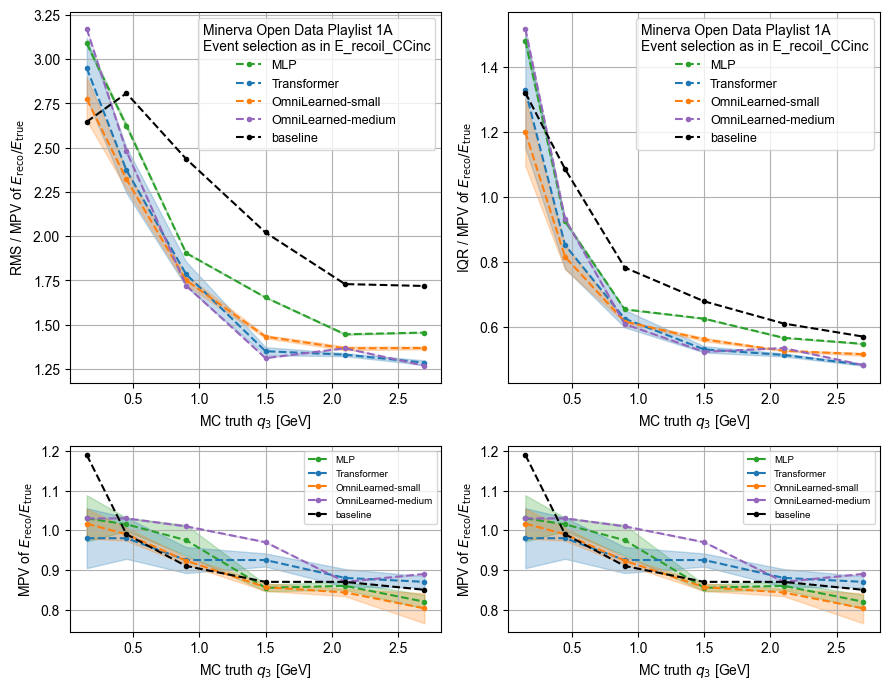

In [11]:
from eval_E_available_plots import plot_rms_iqr, plot_rms_iqr_with_uncertainty

clrs_dict_full = {
    "Transformer": "#1f77b4",   # a nice blue
    "OmniLearned-small": "#ff7f0e",    # a vibrant orange
    "MLP": "#2ca02c",           # a pleasant green
    "OmniLearned-medium": "#9467bd",   # a pretty purple
}

fig_i = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    q3_bins=[0, 0.3, 0.6, 1.2, 1.8, 2.4, 3.0, 100],
    show_q3_histograms=True,
    return_hist_fig=False,
    suppress_errors=False,
    use_cc_selection=2,
    colors=clrs_dict_full,
    text="Minerva Open Data Playlist 1A\nEvent selection as in E_recoil_CCinc"
)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1A.pdf", bbox_inches="tight")
#if fig_i_hist is not None:
#    fig_i_hist.savefig(OUT_DIR / "q3_vs_ratio_hist_full_1A.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1A.pdf")


keys:  dict_keys(['1B', '1A'])
  baseline: RMS = [3.2257329364176592, 2.8568301261201423, 2.2609290821544783, 1.773276054691917, 1.512204049542038, 1.4472189468416221], IQR = [1.6797360275017983, 1.1618682008246586, 0.7671017013403266, 0.625704037703591, 0.5628114524790616, 0.5129377458138086], MPV = [0.71, 0.95, 0.91, 0.91, 0.8300000000000001, 0.81]
E_pred_dict keys for '1A': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer§0', 'Transformer§1', 'Transformer§2', 'Transformer§3', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-medium§0']}
  MLP (Log1p):
    RMS = [4.850748538970947, 3.8451637029647827, 2.6219425201416016, 1.774614930152893, 1.4677148461341858, 1.3421187996864319]
    IQR = [3.167232394218445, 1.9897903501987457, 1.084318995475769, 0.7033122777938843, 0.5870045721530914, 0.534965991973877]
    MPV = [1.0699999630451202, 1.0149999856948853, 0.9950000047683716, 0.8500000238418579, 0.8500000238418579, 0.814999982714653]
  Transfo

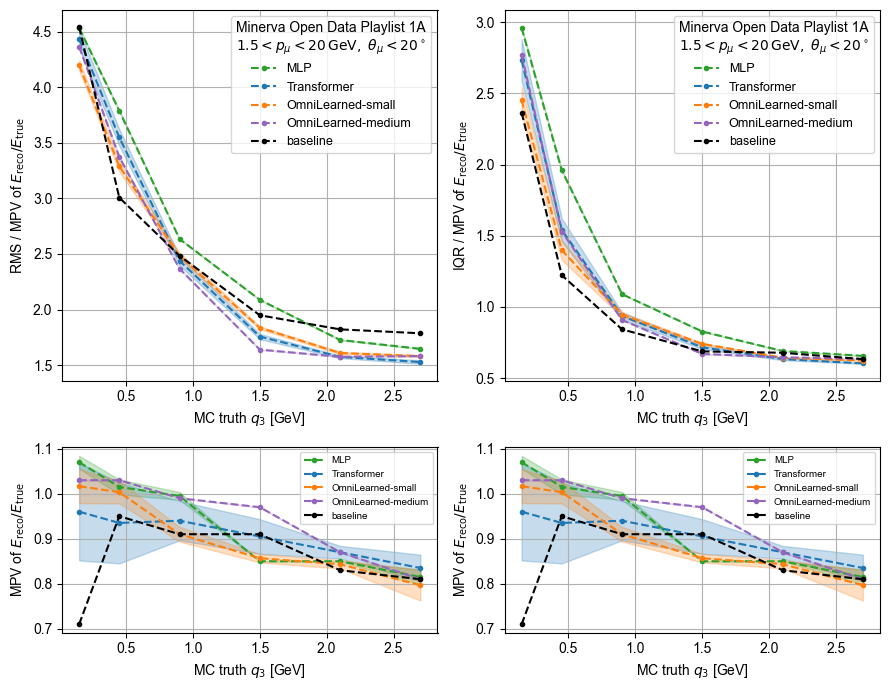

In [ ]:
from eval_E_available_plots import plot_rms_iqr, plot_rms_iqr_with_uncertainty

clrs_dict_full = {
    "Transformer": "#1f77b4",   # a nice blue
    "OmniLearned-small": "#ff7f0e",    # a vibrant orange
    "MLP": "#2ca02c",           # a pleasant green
    "OmniLearned-medium": "#9467bd",   # a pretty purple
}

fig_i = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    q3_bins=[0, 0.3, 0.6, 1.2, 1.8, 2.4, 3.0, 100],
    show_q3_histograms=True,
    return_hist_fig=False,
    suppress_errors=False,
    use_cc_selection=1,
    colors=clrs_dict_full,
    text = (
        "Minerva Open Data Playlist 1A\n"
        r"$1.5 < p_\mu < 20\,\mathrm{GeV},\ \theta_\mu < 20^\circ$"
    )
)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full_muon_selection_only.pdf", bbox_inches="tight")
#if fig_i_hist is not None:
#    fig_i_hist.savefig(OUT_DIR / "q3_vs_ratio_hist_full_1A.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_muon_selection_only.pdf")


keys:  dict_keys(['1B', '1A'])
  baseline: RMS = [3.1519380126743584, 2.7268656891509586, 2.2263049920971496, 1.7388589291621968, 1.518727475622688], IQR = [1.487217046720863, 1.0462488814613664, 0.7105999848299569, 0.5819593962860639, 0.5260957263875167], MPV = [1.11, 1.03, 0.87, 0.87, 0.8300000000000001]
E_pred_dict keys for '1B': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer§0', 'Transformer§1', 'Transformer§2', 'Transformer§3', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-medium§0']}
  MLP (Log1p):
    RMS = [3.142875909805298, 2.5882195830345154, 1.8593750596046448, 1.388279765844345, 1.2329177856445312]
    IQR = [1.3710362613201141, 0.9033733159303665, 0.6327885240316391, 0.5270738899707794, 0.480479896068573]
    MPV = [1.0600000023841858, 1.0399999618530273, 1.0099999904632568, 0.8899999856948853, 0.8500000238418579]
  Transformer (Log1p):
    RMS = [2.8266876339912415, 2.293911576271057, 1.6372633278369904, 1.2171721160411835

TypeError: cannot unpack non-iterable Figure object

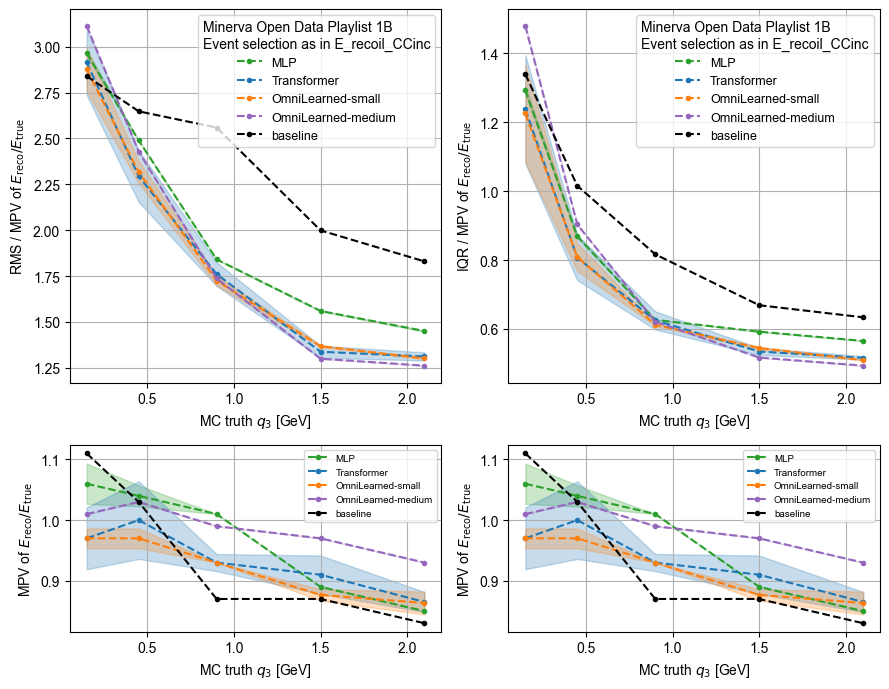

In [27]:
from eval_E_available_plots import plot_rms_iqr, plot_rms_iqr_with_uncertainty

fig_i, values = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1B"],
    dataset_to_plot="1B",
    baseline_run=baseline_run,
    show_q3_histograms=True,   # must be True to produce histograms (param is ignored, but for clarity)
    return_hist_fig=True,
    suppress_errors=True,
    colors=clrs_dict_full,
    text="Minerva Open Data Playlist 1B\nEvent selection as in E_recoil_CCinc",
)
# The returned `values` dict contains the histograms used for IQR calculation:
histograms = values.get("histograms", None)
# Now `histograms` will be a dict (if it is provided by the plotting function)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1B.pdf", bbox_inches="tight")
#if fig_i_hist is not None:
#    fig_i_hist.savefig(OUT_DIR / "q3_vs_ratio_hist_full_1B.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1B.pdf")

keys:  dict_keys(['1B', '1A'])
  baseline: RMS = [3.148372598935032, 2.7791810405009967, 2.2176398351942384, 1.758116717480389, 1.504561280576312], IQR = [1.571619917564179, 1.0746723295343061, 0.7115179810480453, 0.5896458729592533, 0.5301364134724922], MPV = [1.19, 0.99, 0.91, 0.87, 0.87]
E_pred_dict keys for '1A': {'Log1p': ['MLP§0', 'MLP§1', 'MLP§2', 'MLP§3', 'Transformer§0', 'Transformer§1', 'Transformer§2', 'Transformer§3', 'OmniLearned-small§0', 'OmniLearned-small§1', 'OmniLearned-small§2', 'OmniLearned-medium§0']}
  MLP (Log1p):
    RMS = [3.1814438700675964, 2.6627307534217834, 1.8577376008033752, 1.414291799068451, 1.2435448169708252]
    IQR = [1.5256316363811493, 0.9385534524917603, 0.6366978585720062, 0.5337332934141159, 0.48613882064819336]
    MPV = [1.0299999564886093, 1.0149999856948853, 0.9749999940395355, 0.8550000190734863, 0.8600000143051147]
  Transformer (Log1p):
    RMS = [2.8905749917030334, 2.3253130316734314, 1.651973158121109, 1.2490622103214264, 1.170898675

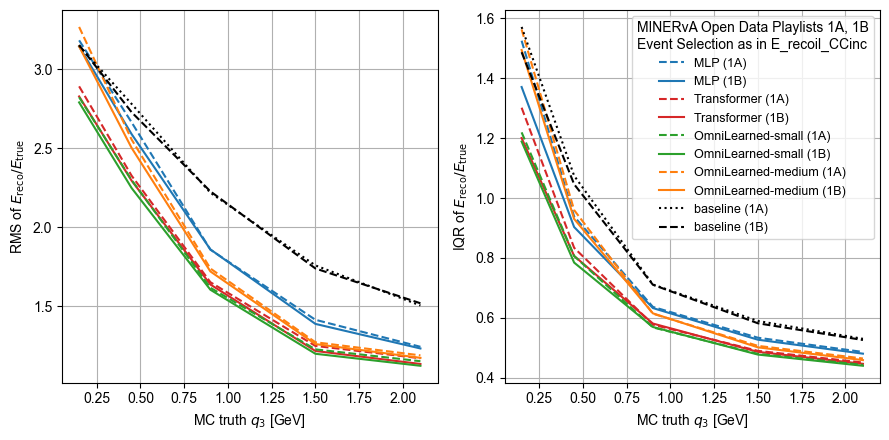

In [19]:
from eval_E_available_plots import plot_rms_iqr_with_uncertainty

# 1A: get per-config means (and close the internal figure)
fig_1A, vals_1A = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    suppress_errors=True,
    return_values=True,
)
plt.close(fig_1A)

# 1B: same
fig_1B, vals_1B = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1B"],
    dataset_to_plot="1B",
    baseline_run=baseline_run,
    suppress_errors=True,
    return_values=True,
)
plt.close(fig_1B)

q3 = vals_1A["q3_bin_mids"]

fig_both, ax = plt.subplots(1, 2, figsize=(9, 4.5))

# Simple color cycle per method
colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])

methods = sorted({
    cfg.split()[0]  # assumes labels like "Transformer1 6M"
    for loss in vals_1A
    if loss not in ("q3_bin_mids", "baseline")
    for cfg in vals_1A[loss].keys()
})
color_by_method = {m: colors[i % len(colors)] for i, m in enumerate(methods)}

for loss in vals_1A:
    if loss in ("q3_bin_mids", "baseline"):
        continue
    for cfg_label, vA in vals_1A[loss].items():
        method = cfg_label.split()[0]
        color = color_by_method.get(method, "tab:gray")

        # 1A mean only
        ax[0].plot(
            q3, vA["rms_mean"], "--", color=color,
            label=f"{method} (1A)"
        )
        ax[1].plot(
            q3, vA["iqr_mean"], "--", color=color,
            label=f"{method} (1A)"
        )

        # 1B mean only, if present
        vB = vals_1B.get(loss, {}).get(cfg_label)
        if vB is not None:
            ax[0].plot(
                q3, vB["rms_mean"], "-",
                color=color, label=f"{method} (1B)"
            )
            ax[1].plot(
                q3, vB["iqr_mean"], "-",
                color=color, label=f"{method} (1B)"
            )

# Optional: baseline line if present
if "baseline" in vals_1A:
    bl = vals_1A["baseline"]
    ax[0].plot(q3, bl["rms"], "k:", label="baseline (1A)")
    ax[1].plot(q3, bl["iqr"], "k:", label="baseline (1A)")
if "baseline" in vals_1B:
    bl = vals_1B["baseline"]
    ax[0].plot(q3, bl["rms"], "k--", label="baseline (1B)")
    ax[1].plot(q3, bl["iqr"], "k--", label="baseline (1B)")

ax[0].set(
    xlabel="MC truth $q_3$ [GeV]",
    ylabel="RMS of $E_{\\mathrm{reco}}/E_{\\mathrm{true}}$",
)
ax[1].set(
    xlabel="MC truth $q_3$ [GeV]",
    ylabel="IQR of $E_{\\mathrm{reco}}/E_{\\mathrm{true}}$",
)

selection_text = (
    "MINERvA Open Data Playlists 1A, 1B\n"
    r"Event Selection as in E_recoil_CCinc"
)

# Rebuild legends with a shared title describing the selection
#leg0 = ax[0].legend(title=selection_text, fontsize=9, loc="upper right")
#leg0.set_title(selection_text)

leg1 = ax[1].legend(title=selection_text, fontsize=9, loc="upper right")
leg1.set_title(selection_text)

ax[0].grid(True)
ax[1].grid(True)

fig_both.tight_layout()
fig_both.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1A_1B.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1A_1B.pdf")

## (II) Residuals by energy – full training dataset

No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_45_20260316_022020 on playlist 1A
No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1A
No settings found for Run_cond_only_full_seed43_20260315_235708 on playlist 1A
No settings found for Run_1203_OLM_regression_-1_seed42_20260314_060257 on playlist 1A
keys:  dict_keys(['1A', '1B'])
Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/residuals_by_energy_full.pdf


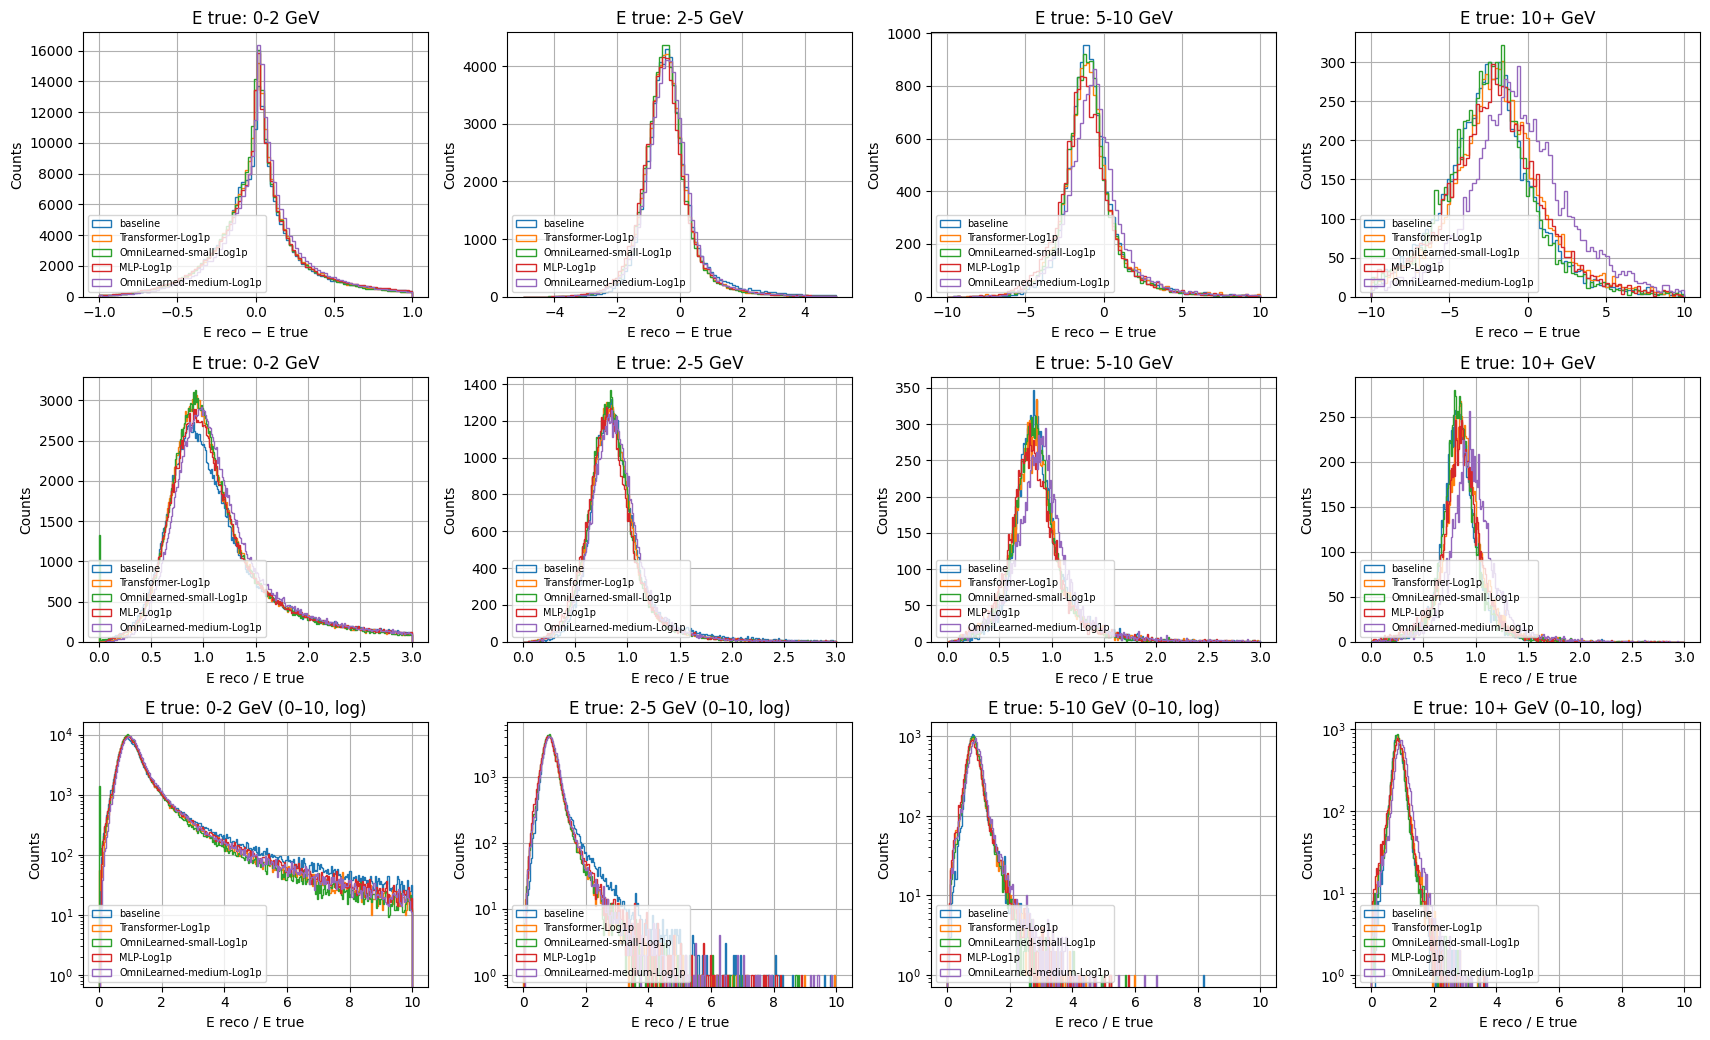

In [ ]:
from eval_E_available_plots import plot_residuals_by_energy
# Existing: training_names_full = {"Log1p": {...}} built above

training_names_full_first_only: dict[str, dict[str, str]] = {}
for loss, models in training_names_full.items():
    training_names_full_first_only[loss] = {}
    for model, runs in models.items():
        if isinstance(runs, list):
            if not runs:
                continue
            training_names_full_first_only[loss][model] = runs[0]
        else:
            training_names_full_first_only[loss][model] = runs

fig_ii = plot_residuals_by_energy(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full_first_only,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    suppress_errors=True,
)
fig_ii.savefig(OUT_DIR / "residuals_by_energy_full.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "residuals_by_energy_full.pdf")



## (III) IQR vs number of training samples – bin 2 (all models)

In [ ]:
# (III) IQR vs number of training samples
# training_names_grouped is constructed inside the plotting cell below.

No settings found for Run_1203_regression_Transformer1_data_cap_200000_seed_42_20260315_174812 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_200000_seed_50_20260316_190300 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_200000_seed_47_20260316_185028 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_200000_seed_49_20260316_185550 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_200000_seed_46_20260316_185028 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_200000_seed_48_20260316_185230 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_100000_seed_46_20260316_184959 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_100000_seed_47_20260316_185026 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_100000_seed_49_20260316_185517 on playlist 1A
No setting

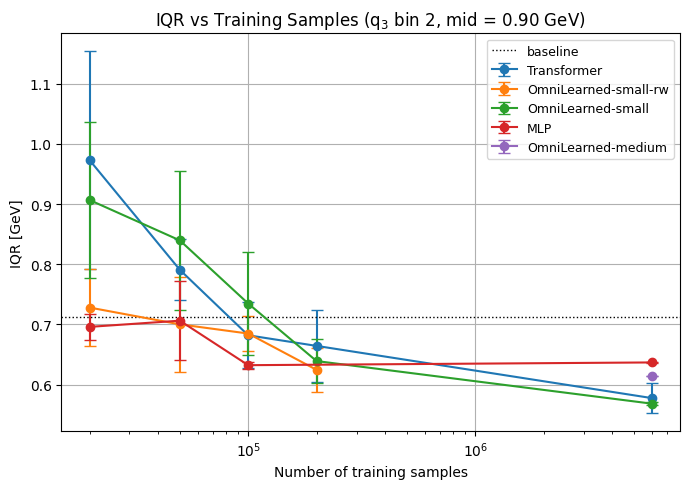

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from eval_E_available_plots import plot_rms_iqr_with_uncertainty

# Build grouped training names for this plot on the fly

def _cap_to_label(cap):
    if cap == -1:
        return "6M"
    if cap >= 1_000_000:
        return f"{cap // 1_000_000}M"
    return f"{cap // 1000}k"

training_names_grouped = {"Log1p": {}}
for model, caps in runs_by_model_cap.items():
    for cap, run_list in sorted(caps.items(), key=lambda x: (x[0] == -1, -x[0] if x[0] > 0 else 0)):
        if not run_list:
            continue
        label = f"{model} {_cap_to_label(cap)}"
        training_names_grouped["Log1p"][label] = run_list

if not training_names_grouped["Log1p"]:
    raise SystemExit("No runs for scaling plot. Check WANDB_TAG.")

_, values = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_grouped,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    return_values=True,
    suppress_errors=True,
)
plt.close()

Q3_BIN_IDX = 2

def _n_samples(label):
    m = re.search(r"(\d+(?:\.\d+)?)\s*([kKmM])\b", label)
    if m:
        return float(m.group(1)) * (1e6 if m.group(2).upper() == "M" else 1e3)
    return 0.0

def _method(label):
    return re.sub(r"\s+\d+(?:\.\d+)?[kKmM]$", "", label)

methods = {}
for loss in values:
    if loss in ("q3_bin_mids", "baseline"):
        continue
    for cfg, v in values[loss].items():
        methods.setdefault(_method(cfg), []).append(
            (_n_samples(cfg), v["iqr_mean"][Q3_BIN_IDX], v["iqr_std"][Q3_BIN_IDX])
        )

for m in methods:
    methods[m].sort()

fig_iii, ax = plt.subplots(figsize=(7, 5))
for method, pts in methods.items():
    xs, ys, yerrs = zip(*pts)
    ax.errorbar(xs, ys, yerr=yerrs, marker="o", capsize=4, label=method)

if "baseline" in values:
    ax.axhline(values["baseline"]["iqr"][Q3_BIN_IDX],
               color="black", linestyle=":", lw=1, label="baseline")

ax.set_xscale("log")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("IQR [GeV]")
q3_mid = values["q3_bin_mids"][Q3_BIN_IDX]
ax.set_title(f"IQR vs Training Samples (q$_3$ bin {Q3_BIN_IDX}, mid = {q3_mid:.2f} GeV)")
ax.legend(fontsize=9)
ax.grid(True)
fig_iii.tight_layout()
fig_iii.savefig(OUT_DIR / "iqr_vs_n_samples_bin2.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "iqr_vs_n_samples_bin2.pdf")

In [ ]:
# For each model, get the values of the field "eval_loss". This is validation loss logged to wandb each 1000 steps
# Use this and make a plot of log flops vs validation loss for each model.

# flops for BS 2048
flops_per_step = {
    "Transformer": 358.5 * 1e9,
    "OmniLearned-small": 1769 * 1e9,
    "MLP": 2.6 * 1e9,
    "OmniLearned-medium": 8035 * 1e9
}


def get_validation_loss_history(run_name, project="minerva-models", with_steps=False):
    """Return array of all logged eval_loss values for a run (from wandb history).
    If with_steps=True, return (steps, losses) for x-axis (e.g. cumulative flops)."""
    import os
    import numpy as np
    import wandb
    api = wandb.Api(timeout=60)
    entity = os.environ.get("WANDB_ENTITY") or getattr(api, "default_entity", None)
    if not entity:
        raise RuntimeError("WANDB_ENTITY not set and wandb default_entity unknown. Run wandb login or set WANDB_ENTITY.")
    path = f"{entity}/{project}"
    runs = api.runs(path, filters={"displayName": run_name})
    run = next(iter(runs), None)
    if run is None:
        raise ValueError(f"Wandb run not found: {run_name!r} in {path}")
    hist = run.history()
    if "eval_loss" not in hist.columns:
        return (np.array([]), np.array([])) if with_steps else np.array([])
    mask = hist["eval_loss"].notna()
    steps = np.asarray(hist["_step"], dtype=float)[mask]
    losses = np.asarray(hist["eval_loss"].dropna(), dtype=float)
    # Keep only every 1000th step (1000, 2000, 3000, ...) as data points
    step_int = np.round(steps).astype(int)
    keep = (step_int >= 1000) & (step_int % 1000 == 0)
    steps, losses = steps[keep], losses[keep]
    # Sort by step and take first occurrence per step (in case of duplicates)
    order = np.argsort(steps)
    steps, losses = steps[order], losses[order]
    _, idx = np.unique(np.round(steps).astype(int), return_index=True)
    steps = steps[np.sort(idx)]
    losses = losses[np.sort(idx)]
    if with_steps:
        return steps, losses
    return losses


#get_validation_loss_history("Run_1203_classifier_Transformer1_data_cap_-1_seed_42_20260313_015120")



Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/log_flops_vs_val_loss.pdf


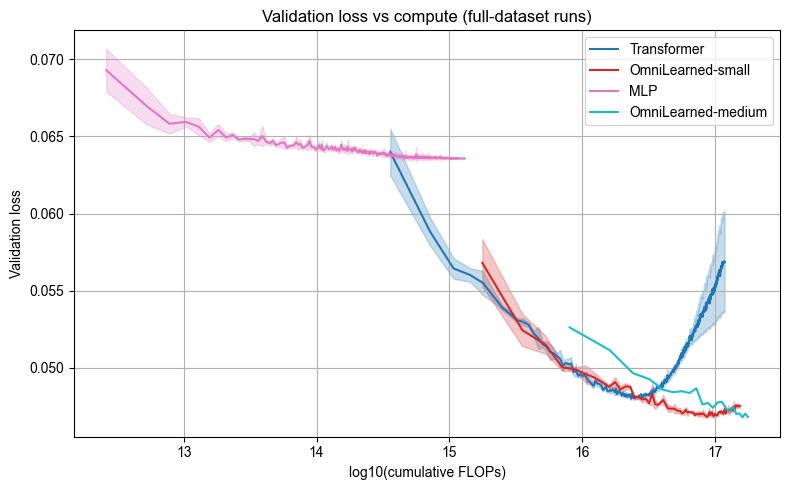

In [24]:
# Log flops vs validation loss: one curve per model; data points every 1000 steps; ±1 sigma band across runs (when available)
import numpy as np
import matplotlib.pyplot as plt
# Runs per model for full dataset (cap=-1); use all seeds when available
runs_per_model = {}
for model in flops_per_step:
    if model not in runs_by_model_cap or -1 not in runs_by_model_cap[model]:
        run_name = training_names_full["Log1p"].get(model)
        if run_name:
            runs_per_model[model] = [run_name]
        continue
    runs_per_model[model] = runs_by_model_cap[model][-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(runs_per_model)))

for (model, run_names), color in zip(runs_per_model.items(), colors):
    flops = flops_per_step[model]
    all_steps, all_losses = [], []
    for rn in run_names:
        st, lo = get_validation_loss_history(rn, with_steps=True)  # already every 1000 steps
        if len(st) > 0 and len(lo) > 0:
            all_steps.append(st)
            all_losses.append(lo)

    if not all_steps:
        continue

    # Full range: union of all steps across runs (no truncation to minimum)
    steps_grid = np.unique(np.concatenate(all_steps)).astype(float)
    if len(steps_grid) == 0:
        continue
    # Interpolate each run onto the common grid (extrapolates with edge values beyond run range)
    losses_aligned = np.array([
        np.interp(steps_grid, st, lo) for st, lo in zip(all_steps, all_losses)
    ])

    mean_loss = np.mean(losses_aligned, axis=0)
    # Std across runs only (when multiple runs); no band for single run
    sigma_loss = np.std(losses_aligned, axis=0) if losses_aligned.shape[0] > 1 else np.zeros_like(mean_loss)

    cum_flops = steps_grid * flops
    x = np.log10(cum_flops + 1)  # +1 to avoid log(0) at step 0
    mask = x <= 17.25
    x_plot = x[mask]
    mean_loss_plot = mean_loss[mask]
    sigma_loss_plot = sigma_loss[mask]
    ax.plot(x_plot, mean_loss_plot, color=color, label=model)
    if losses_aligned.shape[0] > 1:
        ax.fill_between(x_plot, mean_loss_plot - sigma_loss_plot, mean_loss_plot + sigma_loss_plot, alpha=0.25, color=color)

ax.set_xlabel("log10(cumulative FLOPs)")
ax.set_ylabel("Validation loss")
ax.set_title("Validation loss vs compute (full-dataset runs)")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(OUT_DIR / "log_flops_vs_val_loss.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "log_flops_vs_val_loss.pdf")
plt.show()

Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/log_steps_vs_val_loss.pdf


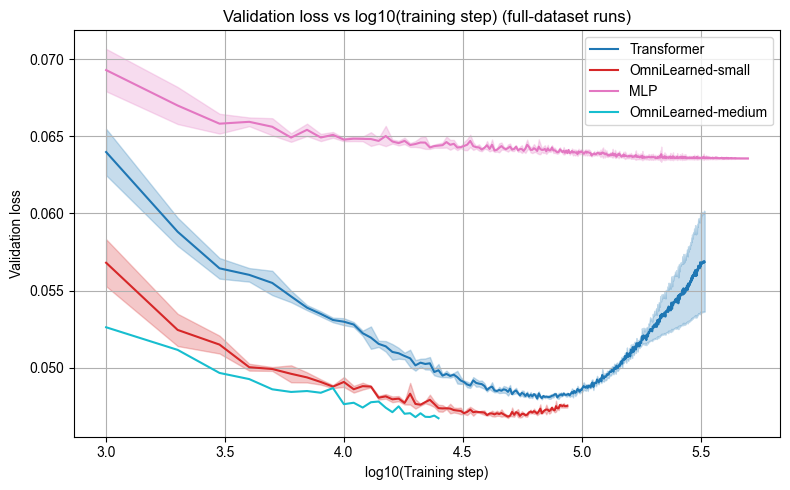

In [26]:
# Plot: Validation loss vs log10(training step), with custom cut for OLM models
fig2, ax2 = plt.subplots(figsize=(8, 5))

for (model, run_names), color in zip(runs_per_model.items(), colors):
    all_steps, all_losses = [], []
    for rn in run_names:
        st, lo = get_validation_loss_history(rn, with_steps=True)
        if len(st) > 0 and len(lo) > 0:
            all_steps.append(st)
            all_losses.append(lo)

    if not all_steps:
        continue

    # Full range: union of all steps across runs (no truncation)
    steps_grid = np.unique(np.concatenate(all_steps)).astype(float)
    if len(steps_grid) == 0:
        continue

    # Interpolate each run onto the common step grid
    losses_aligned = np.array([
        np.interp(steps_grid, st, lo) for st, lo in zip(all_steps, all_losses)
    ])
    mean_loss = np.mean(losses_aligned, axis=0)
    sigma_loss = np.std(losses_aligned, axis=0) if losses_aligned.shape[0] > 1 else np.zeros_like(mean_loss)

    # Custom step cut: OLM models get max 25k, others unbounded
    if 'OmniLearned-medium' in model:
        step_mask = steps_grid <= 25_000
    else:
        step_mask = np.full_like(steps_grid, True, dtype=bool)
    steps_plot = steps_grid[step_mask]
    mean_loss_plot = mean_loss[step_mask]
    sigma_loss_plot = sigma_loss[step_mask]

    # Plot against log10(training step)
    log_steps_plot = np.log10(steps_plot + 1)  # add 1 to avoid log(0)
    ax2.plot(log_steps_plot, mean_loss_plot, color=color, label=model)
    if losses_aligned.shape[0] > 1:
        ax2.fill_between(log_steps_plot, mean_loss_plot - sigma_loss_plot, mean_loss_plot + sigma_loss_plot, alpha=0.25, color=color)

ax2.set_xlabel("log10(Training step)")
ax2.set_ylabel("Validation loss")
ax2.set_title("Validation loss vs log10(training step) (full-dataset runs)")
ax2.legend()
ax2.grid(True)
fig2.tight_layout()
fig2.savefig(OUT_DIR / "log_steps_vs_val_loss.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "log_steps_vs_val_loss.pdf")
plt.show()